# ROC-Based Predictive Analysis: 30-Day Price Movement Classification
## XGBoost Classifier

This notebook implements a supervised machine learning workflow to predict 30-day NVDA price movements using XGBoost.

**Data source:** `model_data.csv` — pre-processed by `DataPipeline.ipynb`  
- Cleaning, feature engineering, multicollinearity reduction, and target variable creation are all handled upstream.
- This notebook loads the ready-to-use dataset and focuses entirely on model training and evaluation.

**Target:** `Price_Direction_30d`
- `1` = Positive 30-day forward ROC (price goes up)
- `0` = Non-positive 30-day forward ROC (price flat or down)


## Initial imports and basic settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 10000 else f'{x:.0f}')
sns.set_style("whitegrid")

## Load data from shared pipeline

Cleaning, feature selection, and target engineering are already done in `DataPipeline.ipynb`.  
No additional preprocessing needed here.


In [3]:
df = pd.read_csv('../model_data.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"NaN values : {df.isna().sum().sum()}")
df.head()

Shape      : (6449, 11)
Date range : 1999-04-05 → 2024-11-15
NaN values : 0


,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
0,1999-04-05,0.0000,0.1659,53.2676,0.0708,-0.0356,59.0079,-0.7949,1.0968,-2430.1594,0
1,1999-04-06,-0.0000,0.1711,50.3047,0.0716,-0.0553,43.7114,-3.0706,0.7777,-2246.2156,1
2,1999-04-07,-0.0000,0.1579,48.0056,0.0673,0.0266,48.0843,-2.4571,1.0271,-2462.7682,0
3,1999-04-08,-0.0000,0.1537,55.1791,0.0652,0.0457,61.1985,-1.3578,1.5934,-2537.5295,0
4,1999-04-09,0.0000,0.1550,56.6647,0.0637,0.0267,75.4039,0.6640,0.5975,-2526.1455,0


In [4]:
print("Features in dataset:")
feature_cols = [c for c in df.columns if c not in ['Date', 'Price_Direction_30d']]
for f in feature_cols:
    print(f"  {f}")
print(f"\nTotal features: {len(feature_cols)}")

Features in dataset:
  MACD_Signal
  BB_Width
  RSI_lag1
  ATR_Pct
  SMA20_Dist
  Stoch_K
  ROC_roll5_mean
  Volume_Ratio
  CCI

Total features: 9


## ROC descriptive statistics

In [5]:
roc = df['ROC_roll5_mean'].dropna()
print("=" * 80)
print("ROC_roll5_mean STATISTICAL ANALYSIS")
print("=" * 80)
print(f"\nTotal observations: {len(roc)}")
print(f"\n{'Metric':<25} {'Value':<15}")
print("-" * 40)
for label, val in [
    ('Mean',     roc.mean()),
    ('Median',   roc.median()),
    ('Std Dev',  roc.std()),
    ('Skewness', roc.skew()),
    ('Kurtosis', roc.kurtosis()),
    ('Min',      roc.min()),
    ('Max',      roc.max()),
    ('IQR',      roc.quantile(0.75) - roc.quantile(0.25)),
]:
    print(f"  {label:<23} {val:<15.4f}")


ROC_roll5_mean STATISTICAL ANALYSIS

Total observations: 6449

Metric                    Value          
----------------------------------------
  Mean                    2.3567         
  Median                  1.9449         
  Std Dev                 12.1904        
  Skewness                0.5763         
  Kurtosis                3.5261         
  Min                     -51.8511       
  Max                     82.9668        
  IQR                     12.9309        


## XGBoost Classifier — Model Training & Evaluation

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)


FEATURES = ['MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI']
TARGET   = 'Price_Direction_30d'

X = df[FEATURES]
y = df[TARGET]

print("=" * 80)
print("DATA PREPARATION FOR XGBOOST")
print("=" * 80)
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape  : {y.shape}")
print(f"Features used : {len(FEATURES)}")
print(f"Total samples : {len(df)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"\nTrain/Test Split:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size : {X_test.shape[0]} samples")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True) * 100}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True) * 100}")


DATA PREPARATION FOR XGBOOST

Features shape: (6449, 9)
Target shape  : (6449,)
Features used : 9
Total samples : 6449

Train/Test Split:
Training set size: 5159 samples
Testing set size : 1290 samples
Train target distribution:
Price_Direction_30d
1   60.1473
0   39.8527
Name: proportion, dtype: float64

Test target distribution:
Price_Direction_30d
1   68.8372
0   31.1628
Name: proportion, dtype: float64


In [7]:
from sklearn.model_selection import TimeSeriesSplit

# Temporal CV — respects chronological order, no future leakage into past folds
tscv = TimeSeriesSplit(n_splits=5)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos   # class imbalance ratio

# ── Moderate regularisation — original unregularised run had train acc 0.88
#    vs test 0.53 (gap 0.35). The new grid uses shallow trees, mild shrinkage,
#    sub-sampling, and mild L1/L2 to bring the gap down without starving
#    the model. ────────────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.05, 0.07],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [3, 5, 10],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0],
    'scale_pos_weight': [1, spw],
    'gamma':            [0, 0.1, 0.3],
}

xgb_base = XGBClassifier(
    eval_metric='auc',          # search & early-stop on AUC, not logloss
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

xgb_search.fit(X_train, y_train)

# ── Final refit with early stopping on the last 15% of training (chronological).
#    n_estimators is data-driven, not memorised. ──────────────────────────────
val_size  = int(len(X_train) * 0.15)
X_tr_es   = X_train.iloc[:-val_size]
y_tr_es   = y_train.iloc[:-val_size]
X_val_es  = X_train.iloc[-val_size:]
y_val_es  = y_train.iloc[-val_size:]

best_params = xgb_search.best_params_.copy()
best_params['n_estimators'] = 1000

best_xgb = XGBClassifier(
    **best_params,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
)
best_xgb.fit(
    X_tr_es, y_tr_es,
    eval_set=[(X_val_es, y_val_es)],
    verbose=False,
)

print("\nBest Parameters (Model 1 — All Features):")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:<20} {v}")
print(f"\nBest CV ROC-AUC                : {xgb_search.best_score_:.4f}")
print(f"Final n_estimators (early-stop): {best_xgb.best_iteration + 1}")

y_pred_train = best_xgb.predict(X_train)
y_pred_test  = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nTest Performance (Model 1 — All 9 Features):")
print(classification_report(y_test, y_pred_test))

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters (Model 1 — All Features):
  subsample            0.8
  scale_pos_weight     1
  reg_lambda           1.0
  reg_alpha            0.1
  n_estimators         200
  min_child_weight     5
  max_depth            4
  learning_rate        0.05
  gamma                0
  colsample_bytree     0.8

Best CV ROC-AUC                : 0.4915
Final n_estimators (early-stop): 1

Test Performance (Model 1 — All 9 Features):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       402
           1       0.69      1.00      0.82       888

    accuracy                           0.69      1290
   macro avg       0.34      0.50      0.41      1290
weighted avg       0.47      0.69      0.56      1290



c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [8]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label, features,
                   cv_score=None):
    """Return a metrics dict and print a formatted summary."""
    y_pred_tr  = model.predict(X_train[features])
    y_pred_te  = model.predict(X_test[features])
    y_proba_te = model.predict_proba(X_test[features])[:, 1]

    metrics = {
        'model':          label,
        'n_features':     len(features),
        'features':       list(features),
        'cv_roc_auc':     cv_score,
        'train_accuracy': accuracy_score(y_train, y_pred_tr),
        'train_f1':       f1_score(y_train, y_pred_tr),
        'test_accuracy':  accuracy_score(y_test, y_pred_te),
        'test_precision': precision_score(y_test, y_pred_te, zero_division=0),
        'test_recall':    recall_score(y_test, y_pred_te, zero_division=0),
        'test_f1':        f1_score(y_test, y_pred_te, zero_division=0),
        'test_roc_auc':   roc_auc_score(y_test, y_proba_te),
        'overfit_gap':    accuracy_score(y_train, y_pred_tr)
                          - accuracy_score(y_test, y_pred_te),
    }
    print(f"\n{'='*80}\n{label.upper()}\n{'='*80}")
    print(f"  Features used  : {len(features)}  →  {features}")
    if cv_score is not None:
        print(f"  CV ROC-AUC     : {cv_score:.4f}")
    print(f"  Train accuracy : {metrics['train_accuracy']:.4f}")
    print(f"  Test accuracy  : {metrics['test_accuracy']:.4f}")
    print(f"  Test F1        : {metrics['test_f1']:.4f}")
    print(f"  Test ROC-AUC   : {metrics['test_roc_auc']:.4f}")
    print(f"  Overfit gap    : {metrics['overfit_gap']:+.4f}  "
          f"(train acc − test acc — lower is better)")
    return metrics


# Registry that every subsequent model will append to.
results = {}
results['Model 1 — All Features'] = evaluate_model(
    best_xgb, X_train, y_train, X_test, y_test,
    label='Model 1 — All Features',
    features=FEATURES,
    cv_score=xgb_search.best_score_,
)

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT — Model 1 (Test Set)")
print("=" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))


MODEL 1 — ALL FEATURES
  Features used  : 9  →  ['MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI']
  CV ROC-AUC     : 0.4915
  Train accuracy : 0.6015
  Test accuracy  : 0.6884
  Test F1        : 0.8154
  Test ROC-AUC   : 0.5628
  Overfit gap    : -0.0869  (train acc − test acc — lower is better)

DETAILED CLASSIFICATION REPORT — Model 1 (Test Set)
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       402
    Positive       0.69      1.00      0.82       888

    accuracy                           0.69      1290
   macro avg       0.34      0.50      0.41      1290
weighted avg       0.47      0.69      0.56      1290



c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

FEATURE IMPORTANCE

Feature importance ranking:
       Feature  Importance
   MACD_Signal      0.1526
       ATR_Pct      0.1477
    SMA20_Dist      0.1279
      BB_Width      0.1156
           CCI      0.1065
ROC_roll5_mean      0.0988
       Stoch_K      0.0957
      RSI_lag1      0.0827
  Volume_Ratio      0.0726


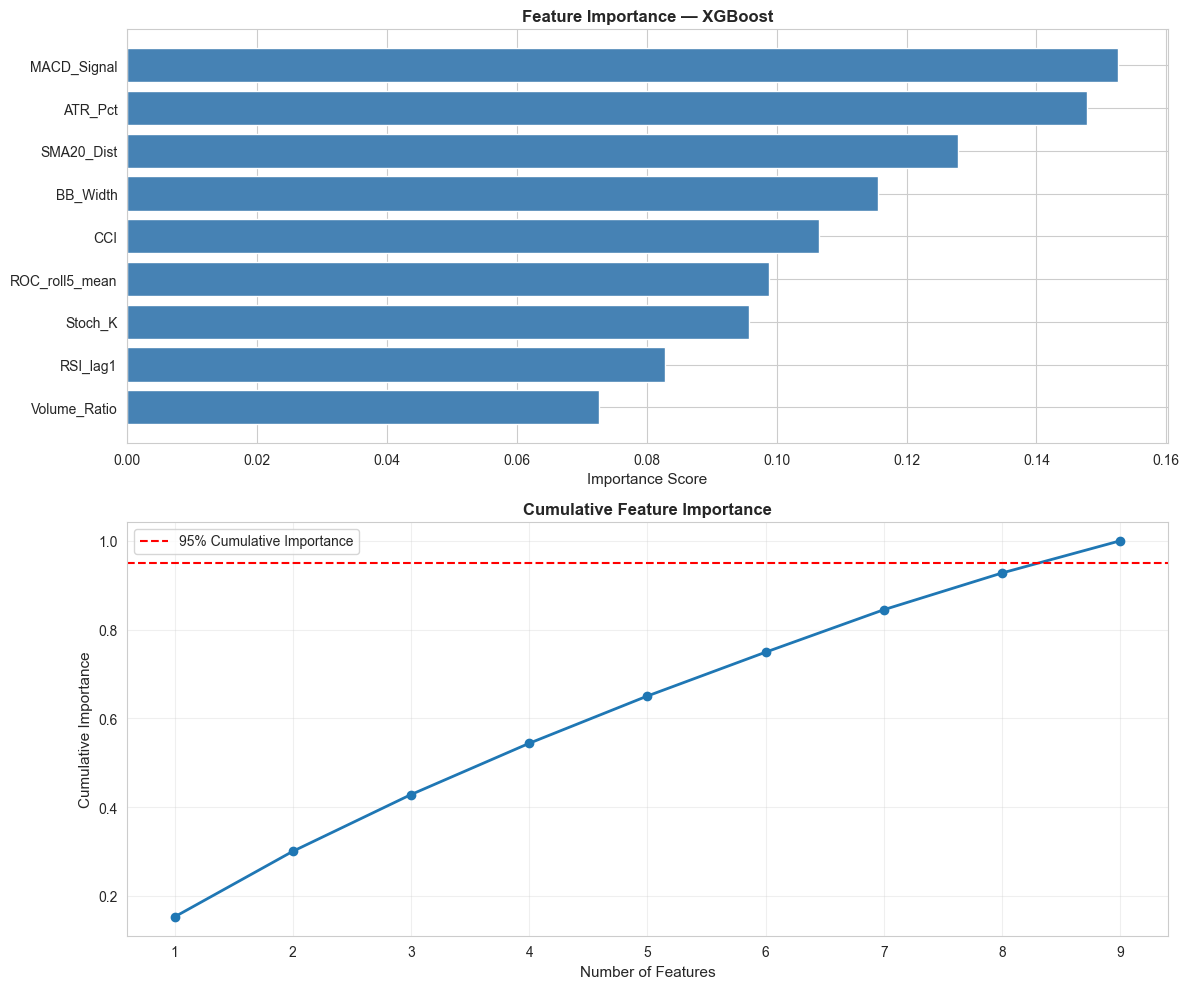


Number of features for 95% cumulative importance: 9


In [9]:
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

feature_importance = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': best_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)

print("\nFeature importance ranking:")
print(feature_importance.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].barh(feature_importance['Feature'], feature_importance['Importance'],
             color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance — XGBoost', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()

cumsum_importance = feature_importance['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum_importance) + 1), cumsum_importance.values,
             marker='o', linestyle='-', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% Cumulative Importance')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

n_features_95 = (cumsum_importance >= 0.95).argmax() + 1
print(f"\nNumber of features for 95% cumulative importance: {n_features_95}")

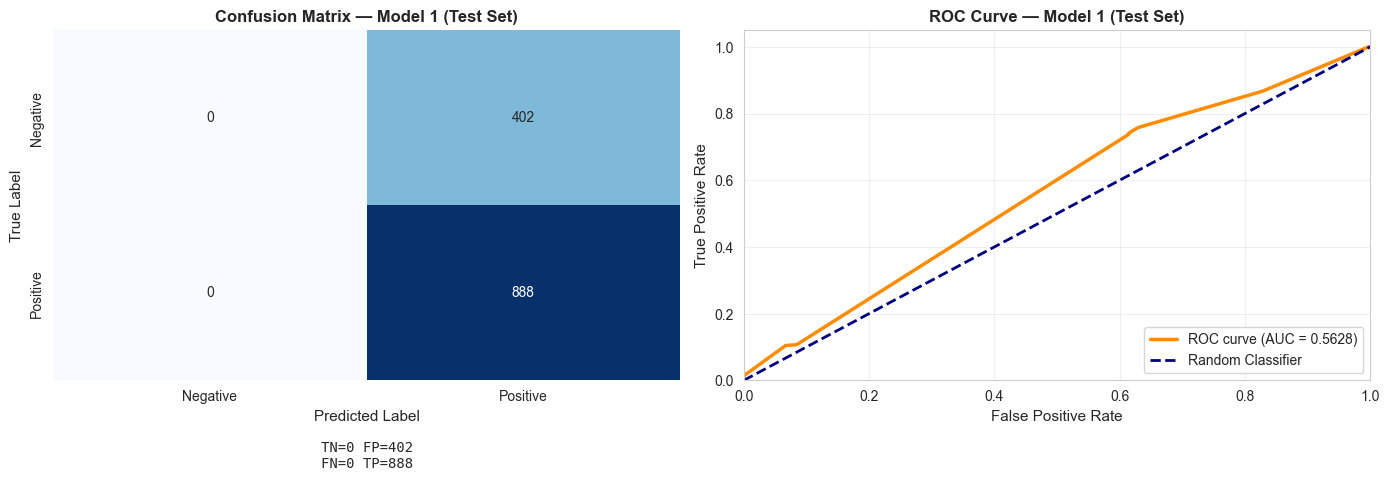

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title('Confusion Matrix — Model 1 (Test Set)',
                  fontweight='bold', fontsize=12)

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.25, f'TN={tn} FP={fp}\nFN={fn} TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             family='monospace')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve — Model 1 (Test Set)',
                  fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [11]:
print("=" * 80)
print("MODEL 1 SUMMARY & PREDICTIONS")
print("=" * 80)

m1 = results['Model 1 — All Features']

predictions_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred_test,
    'Probability': y_pred_proba,
    'Correct':     y_test.values == y_pred_test,
})

print(f"\nTotal Test Predictions: {len(predictions_df)}")
print(f"Correct Predictions   : {predictions_df['Correct'].sum()}")
print(f"Incorrect Predictions : {(~predictions_df['Correct']).sum()}")

print("\nRecent Predictions (Last 10 samples):")
print(predictions_df.tail(10).to_string())

print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 80)
high_conf = (predictions_df['Probability'] >= 0.7) | (predictions_df['Probability'] <= 0.3)
print(f"\nHigh Confidence (prob ≥ 0.7 or ≤ 0.3): "
      f"{high_conf.sum()} ({high_conf.sum()/len(predictions_df)*100:.1f}%)")
print(f"Low  Confidence (0.3 < prob < 0.7)   : "
      f"{(~high_conf).sum()} ({(~high_conf).sum()/len(predictions_df)*100:.1f}%)")

print("\n" + "=" * 80)
print("KEY TAKEAWAYS — MODEL 1")
print("=" * 80)
print(f"• Test accuracy : {m1['test_accuracy']:.2%}")
print(f"• Test ROC-AUC  : {m1['test_roc_auc']:.4f}")
print(f"• Test F1       : {m1['test_f1']:.4f}")
print(f"• Overfit gap   : {m1['overfit_gap']:+.4f}  "
      f"(was 0.3478 in the unregularised run)")
print(f"• Top predictor : {feature_importance.iloc[0]['Feature']} "
      f"(importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"• Class balance : {y_test.value_counts(normalize=True)[1]:.1%} positive in test")
print("=" * 80)

MODEL 1 SUMMARY & PREDICTIONS

Total Test Predictions: 1290
Correct Predictions   : 888
Incorrect Predictions : 402

Recent Predictions (Last 10 samples):
      Actual  Predicted  Probability  Correct
1280       0          1       0.5909    False
1281       0          1       0.5909    False
1282       0          1       0.5909    False
1283       0          1       0.5909    False
1284       0          1       0.5909    False
1285       0          1       0.5909    False
1286       0          1       0.5909    False
1287       0          1       0.5909    False
1288       0          1       0.5909    False
1289       0          1       0.5909    False

PREDICTION CONFIDENCE ANALYSIS

High Confidence (prob ≥ 0.7 or ≤ 0.3): 0 (0.0%)
Low  Confidence (0.3 < prob < 0.7)   : 1290 (100.0%)

KEY TAKEAWAYS — MODEL 1
• Test accuracy : 68.84%
• Test ROC-AUC  : 0.5628
• Test F1       : 0.8154
• Overfit gap   : -0.0869  (was 0.3478 in the unregularised run)
• Top predictor : MACD_Signal (importanc

## Model 2 — Feature-Eliminated XGBoost (95% Cumulative Importance)

Using Model 1's feature importance scores to select the smallest subset of features that together explain **≥ 95%** of the model's predictive power. Model 2 is then retrained on this reduced feature set with the same regularised search and early stopping.

FEATURE IMPORTANCE — MODEL 1 (All 9 Features)

Rank   Feature              Importance      Cumulative
----------------------------------------------------------
  1    MACD_Signal          0.1526         0.1526
  2    ATR_Pct              0.1477         0.3003
  3    SMA20_Dist           0.1279         0.4282
  4    BB_Width             0.1156         0.5437
  5    CCI                  0.1065         0.6503
  6    ROC_roll5_mean       0.0988         0.7490
  7    Stoch_K              0.0957         0.8447
  8    RSI_lag1             0.0827         0.9274
  9    Volume_Ratio         0.0726         1.0000  ← 95% cut

→ Retaining 9 features — cumulative importance: 100.00%
→ Dropped  : none


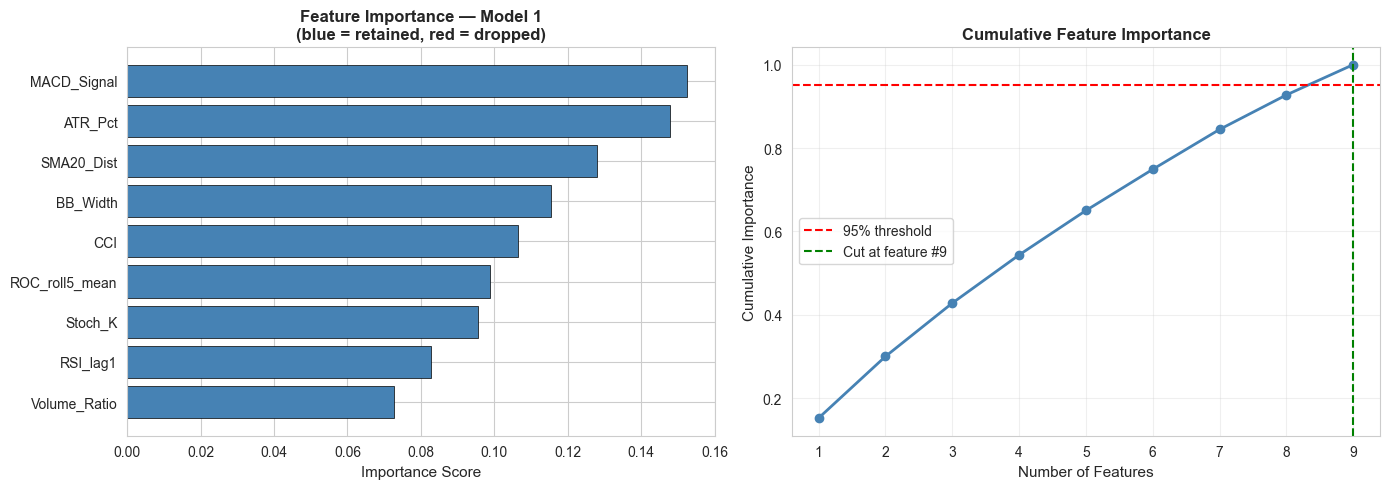

In [12]:
# ── Feature selection: retain features up to 95% cumulative importance ───────
print("=" * 80)
print("FEATURE IMPORTANCE — MODEL 1 (All 9 Features)")
print("=" * 80)

feature_importance_m1 = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': best_xgb.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feature_importance_m1['Cumulative'] = feature_importance_m1['Importance'].cumsum()

print(f"\n{'Rank':<6} {'Feature':<20} {'Importance':<15} {'Cumulative'}")
print("-" * 58)
for i, row in feature_importance_m1.iterrows():
    prev_cum = feature_importance_m1.iloc[i - 1]['Cumulative'] if i > 0 else 0
    marker = "  ← 95% cut" if row['Cumulative'] >= 0.95 and prev_cum < 0.95 else ""
    print(f"  {i+1:<4} {row['Feature']:<20} {row['Importance']:.4f}"
          f"{'':>8} {row['Cumulative']:.4f}{marker}")

# Smallest set of features whose cumulative importance reaches 95%.
n_features_95 = int((feature_importance_m1['Cumulative'] < 0.95).sum()) + 1
n_features_95 = min(n_features_95, len(FEATURES))
FEATURES_M2   = feature_importance_m1.iloc[:n_features_95]['Feature'].tolist()
dropped_feats = feature_importance_m1.iloc[n_features_95:]['Feature'].tolist()

print(f"\n→ Retaining {len(FEATURES_M2)} features — cumulative importance: "
      f"{feature_importance_m1.iloc[n_features_95-1]['Cumulative']:.2%}")
print(f"→ Dropped  : {dropped_feats if dropped_feats else 'none'}")

# ── Visualise ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue' if f in FEATURES_M2 else '#d62728'
          for f in feature_importance_m1['Feature']]
axes[0].barh(feature_importance_m1['Feature'], feature_importance_m1['Importance'],
             color=colors, edgecolor='black', linewidth=0.5)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance — Model 1\n(blue = retained, red = dropped)',
                  fontweight='bold', fontsize=12)

axes[1].plot(range(1, len(feature_importance_m1) + 1),
             feature_importance_m1['Cumulative'],
             marker='o', linewidth=2, color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axvline(n_features_95, color='green', linestyle='--', linewidth=1.5,
                label=f'Cut at feature #{n_features_95}')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [13]:
# ── Retrain XGBoost on the reduced feature set with the same regularised
#    search space, then early-stop on the validation tail. ───────────────────
X_train_m2 = X_train[FEATURES_M2]
X_test_m2  = X_test[FEATURES_M2]

xgb_search_m2 = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='auc', random_state=42,
                            n_jobs=-1, tree_method='hist'),
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
xgb_search_m2.fit(X_train_m2, y_train)

best_params_m2 = xgb_search_m2.best_params_.copy()
best_params_m2['n_estimators'] = 1000

best_xgb_m2 = XGBClassifier(
    **best_params_m2,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
)
best_xgb_m2.fit(
    X_train_m2.iloc[:-val_size], y_train.iloc[:-val_size],
    eval_set=[(X_train_m2.iloc[-val_size:], y_train.iloc[-val_size:])],
    verbose=False,
)

print("\nBest Parameters (Model 2 — 95% Importance Subset):")
for k, v in xgb_search_m2.best_params_.items():
    print(f"  {k:<20} {v}")
print(f"\nBest CV ROC-AUC                : {xgb_search_m2.best_score_:.4f}")
print(f"Final n_estimators (early-stop): {best_xgb_m2.best_iteration + 1}")

results['Model 2 — 95% Importance'] = evaluate_model(
    best_xgb_m2, X_train, y_train, X_test, y_test,
    label='Model 2 — 95% Importance',
    features=FEATURES_M2,
    cv_score=xgb_search_m2.best_score_,
)

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT — Model 2 (Test Set)")
print("=" * 80)
y_pred_test_m2 = best_xgb_m2.predict(X_test_m2)
print(classification_report(y_test, y_pred_test_m2,
                            target_names=['Negative', 'Positive']))

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters (Model 2 — 95% Importance Subset):
  subsample            0.9
  scale_pos_weight     1
  reg_lambda           1.0
  reg_alpha            0.1
  n_estimators         200
  min_child_weight     3
  max_depth            4
  learning_rate        0.05
  gamma                0
  colsample_bytree     0.6

Best CV ROC-AUC                : 0.4923
Final n_estimators (early-stop): 3

MODEL 2 — 95% IMPORTANCE
  Features used  : 9  →  ['MACD_Signal', 'ATR_Pct', 'SMA20_Dist', 'BB_Width', 'CCI', 'ROC_roll5_mean', 'Stoch_K', 'RSI_lag1', 'Volume_Ratio']
  CV ROC-AUC     : 0.4923
  Train accuracy : 0.6015
  Test accuracy  : 0.6884
  Test F1        : 0.8154
  Test ROC-AUC   : 0.5946
  Overfit gap    : -0.0869  (train acc − test acc — lower is better)

DETAILED CLASSIFICATION REPORT — Model 2 (Test Set)
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       402
    Positive      

c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cagan\Documents\GitHub\BasicStockPricePrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

## Model Comparison & Best-Model Selection

Both models are scored on the same held-out test set (last 20% of the timeline). The winner is chosen by **test ROC-AUC** with the train→test accuracy gap shown alongside as an overfit sanity check.

MODEL COMPARISON — sorted by test ROC-AUC
                   model  n_features  cv_roc_auc  train_accuracy  test_accuracy  test_precision  test_recall  test_f1  test_roc_auc  overfit_gap
Model 2 — 95% Importance           9      0.4923          0.6015         0.6884          0.6884       1.0000   0.8154        0.5946      -0.0869
  Model 1 — All Features           9      0.4915          0.6015         0.6884          0.6884       1.0000   0.8154        0.5628      -0.0869

WINNING MODEL
  Model         : Model 2 — 95% Importance
  # features    : 9
  Features      : ['MACD_Signal', 'ATR_Pct', 'SMA20_Dist', 'BB_Width', 'CCI', 'ROC_roll5_mean', 'Stoch_K', 'RSI_lag1', 'Volume_Ratio']
  CV ROC-AUC    : 0.4923
  Test ROC-AUC  : 0.5946
  Test accuracy : 0.6884
  Test F1       : 0.8154
  Overfit gap   : -0.0869


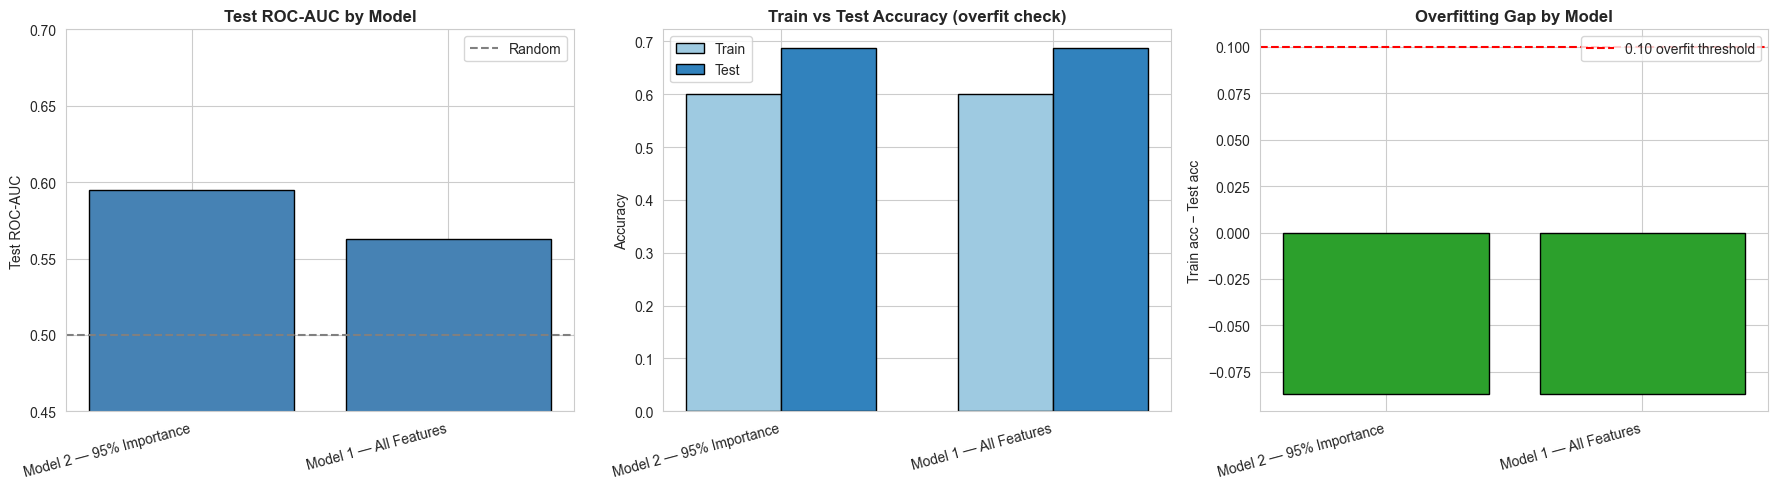

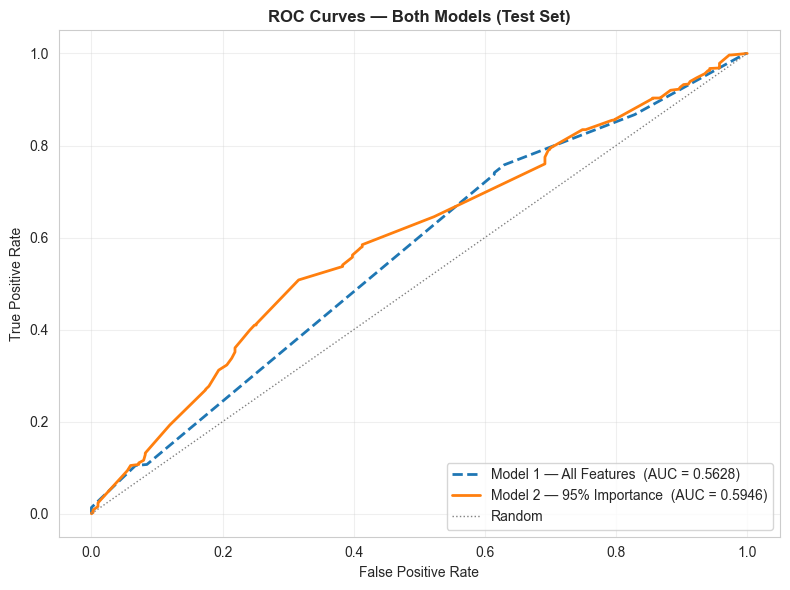


FINAL RECOMMENDATION
→ Use Model 2 — 95% Importance with features: ['MACD_Signal', 'ATR_Pct', 'SMA20_Dist', 'BB_Width', 'CCI', 'ROC_roll5_mean', 'Stoch_K', 'RSI_lag1', 'Volume_Ratio']
  Expected test ROC-AUC: 0.5946


In [14]:
# ── Build comparison frame ──────────────────────────────────────────────────
comparison_df = pd.DataFrame(list(results.values()))[
    ['model', 'n_features', 'cv_roc_auc',
     'train_accuracy', 'test_accuracy',
     'test_precision', 'test_recall', 'test_f1', 'test_roc_auc',
     'overfit_gap']
].sort_values('test_roc_auc', ascending=False).reset_index(drop=True)

print("=" * 110)
print("MODEL COMPARISON — sorted by test ROC-AUC")
print("=" * 110)
print(comparison_df.to_string(index=False))

# ── Pick the winner ─────────────────────────────────────────────────────────
winner_row   = comparison_df.iloc[0]
winner_label = winner_row['model']
winner_meta  = results[winner_label]

print("\n" + "=" * 80)
print("WINNING MODEL")
print("=" * 80)
print(f"  Model         : {winner_label}")
print(f"  # features    : {winner_row['n_features']}")
print(f"  Features      : {winner_meta['features']}")
print(f"  CV ROC-AUC    : {winner_row['cv_roc_auc']:.4f}")
print(f"  Test ROC-AUC  : {winner_row['test_roc_auc']:.4f}")
print(f"  Test accuracy : {winner_row['test_accuracy']:.4f}")
print(f"  Test F1       : {winner_row['test_f1']:.4f}")
print(f"  Overfit gap   : {winner_row['overfit_gap']:+.4f}")

# ── Visual comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(comparison_df))
labels = comparison_df['model'].tolist()

axes[0].bar(x, comparison_df['test_roc_auc'], color='steelblue',
            edgecolor='black')
axes[0].axhline(0.5, color='grey', linestyle='--', label='Random')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha='right')
axes[0].set_ylabel('Test ROC-AUC')
axes[0].set_title('Test ROC-AUC by Model', fontweight='bold')
axes[0].set_ylim(0.45, max(0.7, comparison_df['test_roc_auc'].max() + 0.05))
axes[0].legend()

width = 0.35
axes[1].bar(x - width/2, comparison_df['train_accuracy'], width,
            label='Train', color='#9ecae1', edgecolor='black')
axes[1].bar(x + width/2, comparison_df['test_accuracy'], width,
            label='Test',  color='#3182bd', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy (overfit check)', fontweight='bold')
axes[1].legend()

colors = ['#d62728' if g > 0.10 else '#2ca02c'
          for g in comparison_df['overfit_gap']]
axes[2].bar(x, comparison_df['overfit_gap'], color=colors, edgecolor='black')
axes[2].axhline(0.10, color='red', linestyle='--',
                label='0.10 overfit threshold')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=15, ha='right')
axes[2].set_ylabel('Train acc − Test acc')
axes[2].set_title('Overfitting Gap by Model', fontweight='bold')
axes[2].legend()

plt.tight_layout(); plt.show()

# ── ROC curves of each model on the same axes ──────────────────────────────
plt.figure(figsize=(8, 6))
for label, model, feats in [
    ('Model 1 — All Features',   best_xgb,    FEATURES),
    ('Model 2 — 95% Importance', best_xgb_m2, FEATURES_M2),
]:
    proba = model.predict_proba(X_test[feats])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    style = '-' if label == winner_label else '--'
    plt.plot(fpr, tpr, style, lw=2,
             label=f'{label}  (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle=':', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Both Models (Test Set)', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n" + "=" * 80)
print("FINAL RECOMMENDATION")
print("=" * 80)
print(f"→ Use {winner_label} with features: {winner_meta['features']}")
print(f"  Expected test ROC-AUC: {winner_row['test_roc_auc']:.4f}")
print("=" * 80)